In [71]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from tqdm import tqdm


### Loading in the Data


In [84]:
# Notebook cell 2: Load and Prepare Data
features = pd.read_csv("data/All_features_corrected_final_patient.csv")
labels = pd.read_csv("data/All_model.csv", header=None, names=["TumourModel"], skiprows=1)

df = pd.concat([features, labels], axis=1)
df["TumourModel"] = LabelEncoder().fit_transform(df["TumourModel"])  # 0=Basal, 1=Luminal

print("Data shape:", df.shape)
df.head(10)


Data shape: (2268, 95)


,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM SmallAreaLowGrayLevelEmphasis,GLSZM ZoneEntropy,GLSZM ZonePercentage,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,TumourModel
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,2.315100e+08,-1.937093e-10,-0.082498,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,0
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,4.821426e+08,-2.053864e-10,-0.082433,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,0
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,2.067381e+08,-2.151032e-10,-0.082486,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,0
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,2.133581e+08,-1.793762e-10,-0.082435,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,0
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,2.561433e+08,-1.935037e-10,-0.082480,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,0
5,10,62.204370,203.481139,1.903292e+06,-223972.715422,66.434042,22.497314,937.665771,50.385605,128.072725,...,2.826933e+08,-1.948756e-10,-0.082498,0.006055,132.403139,1.187810e+06,4.227548,-0.008536,-1.343135e+15,0
6,10,58.954342,193.788940,1.900940e+06,-229578.241909,64.411716,21.275051,860.438110,47.626174,122.059293,...,6.181529e+08,-2.094112e-10,-0.082443,0.004959,129.100591,1.426031e+06,3.838805,-0.008580,-1.341563e+15,0
7,10,60.520738,193.165366,1.900639e+06,-231543.913744,63.493423,20.359573,822.506897,46.665821,122.097256,...,9.826593e+08,-1.687853e-10,-0.082403,0.004423,128.631497,1.487336e+06,3.813342,-0.008584,-1.341206e+15,0
8,10,61.587937,195.608017,1.901263e+06,-232765.016674,64.310833,21.120937,851.327881,47.337724,123.831887,...,1.088356e+09,-1.622239e-10,-0.082421,0.004684,128.215734,1.505439e+06,3.736175,-0.008597,-1.340993e+15,0
9,104,105.531123,252.956763,1.893494e+06,-156943.982163,73.162018,3.641592,526.084534,45.778278,178.953387,...,4.586890e+08,-1.071634e-10,-0.081783,0.000804,141.363718,4.453179e+05,7.581497,-0.007443,-1.401968e+15,0


<Axes: xlabel='TumourModel'>

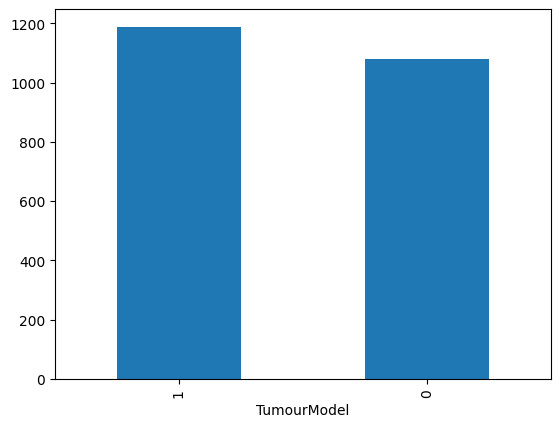

In [85]:
df["TumourModel"].value_counts().plot(kind="bar")

### Sensitivity Analysis (ANOVA)

In [86]:
# Notebook cell 3: η² calculation using F-statistics
X = df.drop(columns=["TumourModel", "PatientName"])
y = df["TumourModel"]

F_vals, p_vals = f_classif(X, y)
eta_squared = F_vals / (F_vals + df.shape[0] - 2)

eta_df = pd.DataFrame({
    "Feature": X.columns,
    "eta_squared": eta_squared,
    "p_value": p_vals
}).sort_values("eta_squared", ascending=False)

eta_df.head(10)


,Feature,eta_squared,p_value
14,FO Skewness,0.221161,3.641321e-125
0,FO 10Percentile,0.157595,1.736133e-86
8,FO Mean,0.153136,6.973989e-84
13,FO RootMeanSquared,0.130800,4.867688e-71
9,FO Median,0.125650,4.009557e-68
1,FO 90Percentile,0.124867,1.108618e-67
5,FO Kurtosis,0.121728,6.486254e-66
15,FO TotalEnergy,0.106596,1.763036e-57
2,FO Energy,0.106594,1.766553e-57
11,FO Range,0.096732,4.677917e-52


/var/folders/0c/1f93j1715l540q8ln1j7wkr40000gp/T/ipykernel_65130/1110830980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="eta_squared", y="Feature", data=eta_df.head(20), palette="viridis")


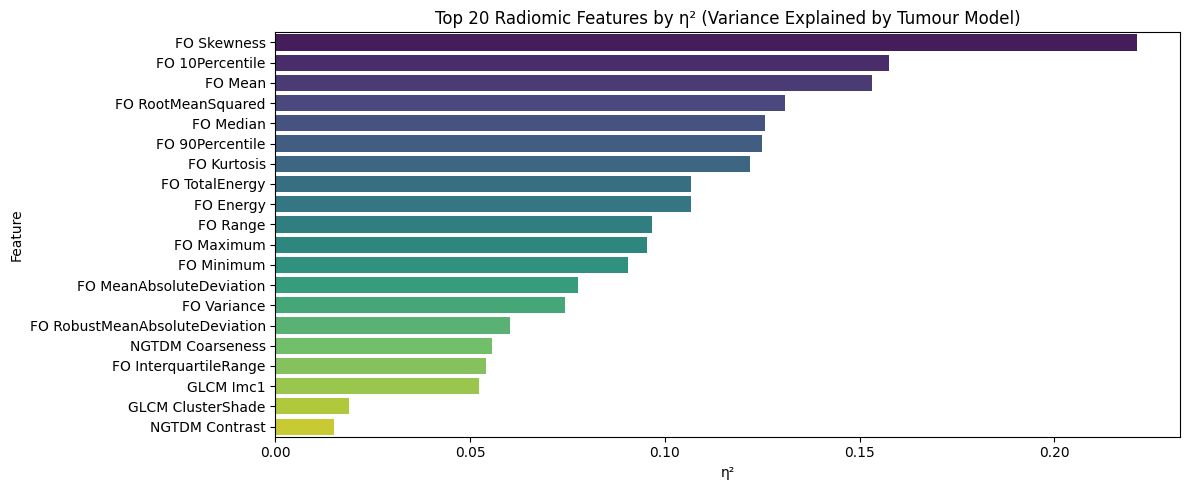

In [87]:
# Notebook cell 4: Plot η² values
plt.figure(figsize=(12, 5))
sns.barplot(x="eta_squared", y="Feature", data=eta_df.head(20), palette="viridis")
plt.title("Top 20 Radiomic Features by η² (Variance Explained by Tumour Model)")
plt.xlabel("η²")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [113]:
import pandas as pd
import os

# Load radiomic features (no metadata)
df_features = pd.read_csv("data/All_features_corrected_final_patient.csv")

# Load and concatenate all 12 metadata files
folder = "data/ModelsUncorrected"  # update to your path
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]

metadata_list = []
for f in sorted(csv_files):  # ensure consistent order!
    df = pd.read_csv(os.path.join(folder, f), usecols=["PatientName", "Model", "Wavelength", "GLbins"])
    df["Reconstruction"] = "MB" if "_MB" in f else "BP"
    metadata_list.append(df)

df_metadata = pd.concat(metadata_list, ignore_index=True)

# Final check
assert len(df_features) == len(df_metadata), "Row count mismatch!"

# Concatenate by row order
df_combined = pd.concat([df_features, df_metadata.drop(columns="PatientName")], axis=1)

# Convert to categorical for ANOVA
for col in ["Model", "Wavelength", "GLbins", "Reconstruction"]:
    df_combined[col] = df_combined[col].astype("category")

print("Combined shape:", df_combined.shape)
df_combined.head()


Combined shape: (2268, 98)


,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,GLbins,Model,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,702116.533708,5.431388,-0.008386,-1.346671e+15,128,basal,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,635045.201104,5.512007,-0.008424,-1.347603e+15,128,basal,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,775115.290530,5.212363,-0.008415,-1.346064e+15,128,basal,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,562043.917443,5.830865,-0.008369,-1.347809e+15,128,basal,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,688475.202442,5.429985,-0.008394,-1.346774e+15,128,basal,770,BP


In [118]:
# Option 1: Use all columns that are not metadata
meta_cols = ["PatientName", "Model", "GLbins", "Wavelength", "Reconstruction"]
feature_cols = [col for col in df_combined.columns if col not in meta_cols]
print("len(feature_cols):", len(feature_cols)) 


len(feature_cols): 93


In [119]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from tqdm import tqdm
import numpy as np

eta2_list = []

for feature in tqdm(feature_cols):
    try:
        formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
        model = ols(formula, data=df_combined).fit()
        aov_table = sm.stats.anova_lm(model, typ=2)

        # Calculate eta²
        ss_total = aov_table["sum_sq"].sum()
        eta2 = (aov_table["sum_sq"] / ss_total).to_dict()
        eta2["Feature"] = feature
        eta2_list.append(eta2)
    except Exception as e:
        print(f"Failed on {feature}: {e}")


100%|██████████| 93/93 [00:02<00:00, 34.16it/s]


In [121]:
eta2_df = pd.DataFrame(eta2_list).fillna(0).set_index("Feature")

# Rename "Residual" to "Error"
eta2_df = eta2_df.rename(columns={"Residual": "Error"})

# Strip "C(...)" from factor names
eta2_df.columns = eta2_df.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

# Reorder columns
eta2_df = eta2_df[["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]]


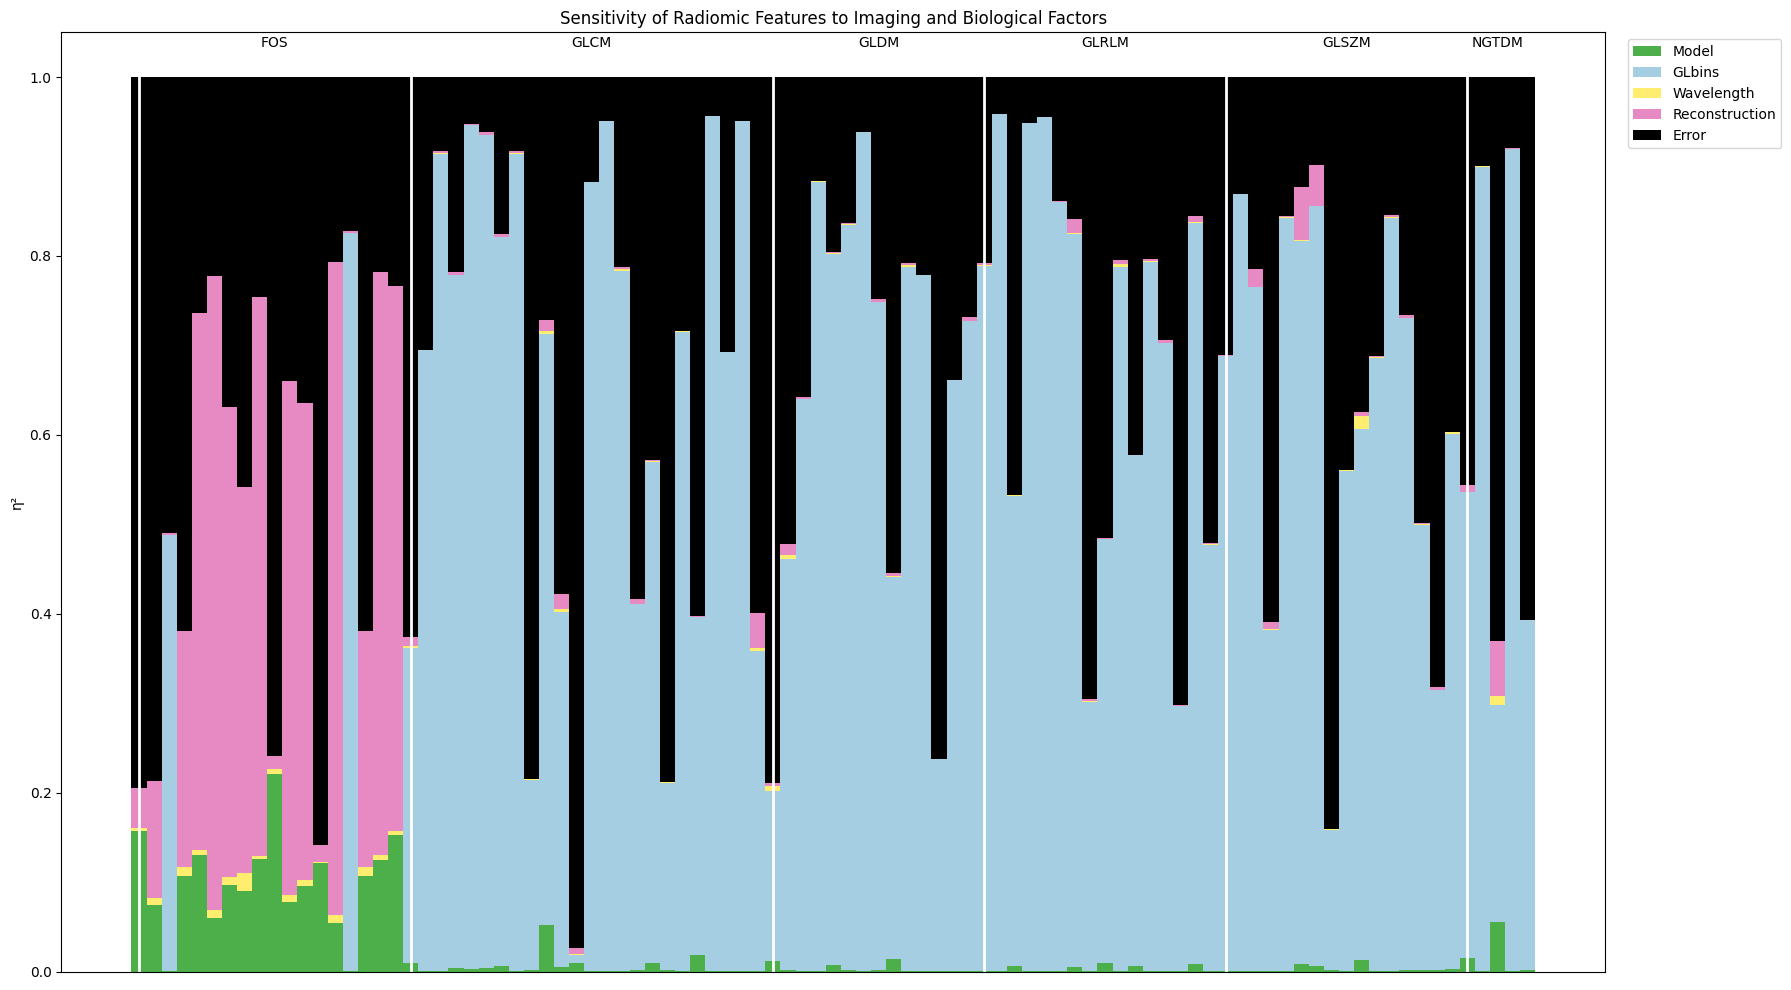

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Define consistent color mapping from the paper
color_map = {
    "Model": "#4daf4a",          # green
    "GLbins": "#a6cee3",         # light blue
    "Wavelength": "#ffed6f",     # yellow
    "Reconstruction": "#e78ac3", # pink
    "Error": "#000000"           # black
}

# Sort by feature group for aesthetics (optional)
def get_feature_group(feature):
    feature = feature.lower()
    if "fo " in feature: return "FOS"
    if "glcm" in feature: return "GLCM"
    if "gldm" in feature: return "GLDM"
    if "glrlm" in feature: return "GLRLM"
    if "glszm" in feature: return "GLSZM"
    if "ngtdm" in feature: return "NGTDM"
    return "Other"

eta2_df["Group"] = eta2_df.index.map(get_feature_group)
eta2_sorted = eta2_df.sort_values("Group")

# Plot
fig, ax = plt.subplots(figsize=(18, 10))
bottom = np.zeros(len(eta2_sorted))

ordered_factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
for factor in ordered_factors:
    ax.bar(
        x=np.arange(len(eta2_sorted)),
        height=eta2_sorted[factor],
        bottom=bottom,
        color=color_map[factor],
        width=1.0,
        label=factor
    )
    bottom += eta2_sorted[factor].values

# Draw white lines between groups
group_change_idx = eta2_sorted["Group"].ne(eta2_sorted["Group"].shift()).to_numpy().nonzero()[0]
for idx in group_change_idx:
    ax.axvline(idx, color="white", linewidth=2)

# Add group labels above bars
group_midpoints = []
prev = 0
for idx in list(group_change_idx[1:]) + [len(eta2_sorted)]:
    mid = (prev + idx) // 2
    group_midpoints.append(mid)
    prev = idx

group_names = eta2_sorted["Group"].drop_duplicates().tolist()
for x, label in zip(group_midpoints, group_names):
    ax.text(x, 1.03, label, ha="center", va="bottom", fontsize=10)

# Final formatting
ax.set_ylabel("η²")
ax.set_ylim(0, 1.05)
ax.set_xticks([])
ax.set_title("Sensitivity of Radiomic Features to Imaging and Biological Factors")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Feature Selection and Machine Learning Analysis

In [66]:
from sklearn.feature_selection import f_classif
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Set up data
X = df.drop(columns=["TumourModel"], errors="ignore")  # Drop non-feature cols
y = df["TumourModel"]

# Run ANOVA
F_vals, p_vals = f_classif(X, y)

# Multiple testing correction (Benjamini-Hochberg, FDR = 0.25 like in the paper)
rejected, pvals_corrected, _, _ = multipletests(p_vals, alpha=0.25, method='fdr_bh')

# Create DataFrame
anova_df = pd.DataFrame({
    "Feature": X.columns,
    "F_stat": F_vals,
    "p_value": p_vals,
    "Corrected_p": pvals_corrected,
    "Selected": rejected
})

# Sort by significance
anova_df = anova_df.sort_values("Corrected_p")
selected_features = anova_df[anova_df["Selected"]]["Feature"].tolist()

print(f"Selected {len(selected_features)} features at FDR 25%")
anova_df.head(10)


Selected 53 features at FDR 25%


,Feature,F_stat,p_value,Corrected_p,Selected
14,FO Skewness,643.460066,3.641321e-125,3.386428e-123,True
0,FO 10Percentile,423.918162,1.736133e-86,8.073018e-85,True
8,FO Mean,409.754744,6.973989e-84,2.161937e-82,True
13,FO RootMeanSquared,340.995003,4.867688e-71,1.131738e-69,True
9,FO Median,325.638051,4.009557e-68,7.457775e-67,True
1,FO 90Percentile,323.319845,1.108618e-67,1.718358e-66,True
5,FO Kurtosis,314.065797,6.486254e-66,8.617451e-65,True
2,FO Energy,270.361067,1.766553e-57,1.825438e-56,True
15,FO TotalEnergy,270.365511,1.763036e-57,1.825438e-56,True
11,FO Range,242.667967,4.677917e-52,4.350463e-51,True


In [67]:
X_selected = X[selected_features]


In [68]:
y = df["TumourModel"]

# Compute correlation matrix
corr_matrix = X_selected.corr().abs()

# Keep one feature from each pair with corr > 0.9
upper = np.triu(corr_matrix, k=1)
to_drop = [column for i, column in enumerate(corr_matrix.columns)
           if any(upper[i, j] > 0.9 for j in range(i+1, len(corr_matrix)))]

X_filtered = X_selected.drop(columns=to_drop)
print(f"Kept {X_filtered.shape[1]} features after correlation filtering.")

Kept 28 features after correlation filtering.


In [69]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "Random Forest": RandomForestClassifier(max_depth=3, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(max_depth=3, n_estimators=100, learning_rate=1.0),
    "SVM (RBF)": SVC(kernel="rbf", gamma=0.05, C=1.0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_filtered, y, cv=cv, scoring="accuracy")
    print(f"{name} Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")


Random Forest Accuracy: 0.929 ± 0.022
Gradient Boosting Accuracy: 1.000 ± 0.000
SVM (RBF) Accuracy: 0.524 ± 0.001
